<a href="https://colab.research.google.com/github/Luis-GCH/Lab-PDI-Equipo-8/blob/Lab-PDI-Equipo-8/Practica%204_Lab%20PDI_Equipo%208.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 4: Procesamiento geométrico y procesamiento de histograma**

## **Parte I**

### **Ejercicio 1: Traslación**

Imágen usada para esta parte:

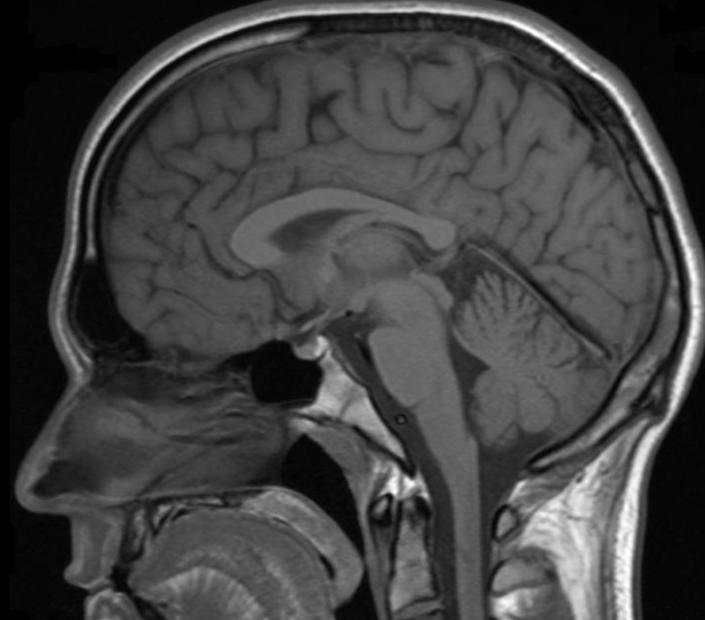

**Código traslación de (50, 30):**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("labpdi4pt2.jpg")
rows, cols = img. shape [ : 2]

M_trans = np.float32([[1, 0, 50], [0, 1, 30]])
img_tras = cv2.warpAffine(img, M_trans, (cols, rows))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original')

plt.subplot(1, 2, 2)
plt.imshow(img_tras)
plt.title('Imágen después de la traslación')


plt.show()


**Resultados**

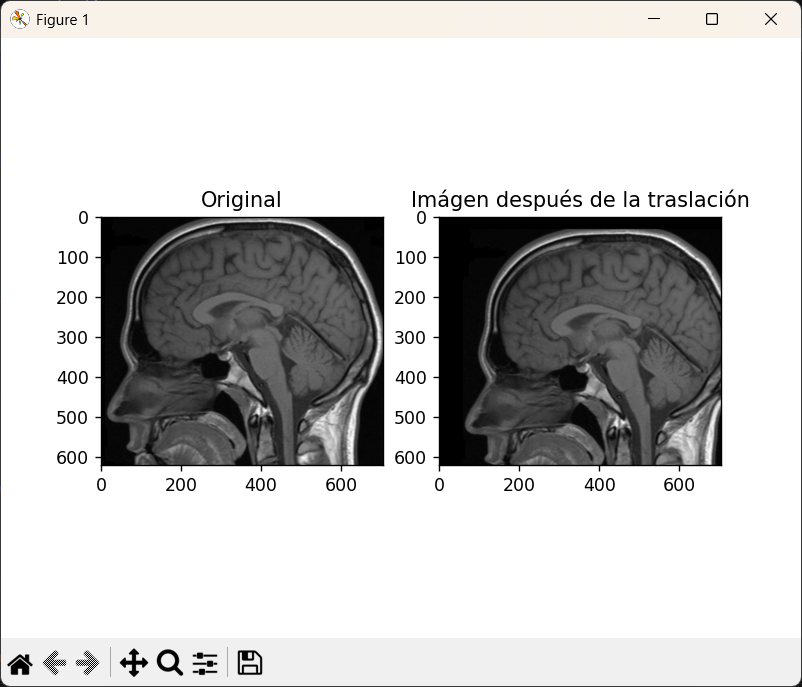

**Código traslación de (20.5, 15.5):**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("labpdi4pt2.jpg")
rows, cols = img. shape [ : 2]

M_trans = np.float32([[1, 0, 20.5], [0, 1, 15.5]])
img_tras = cv2.warpAffine(img, M_trans, (cols, rows))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original')

plt.subplot(1, 2, 2)
plt.imshow(img_tras)
plt.title('Imágen después de la traslación')

plt.show()

**Resultados**

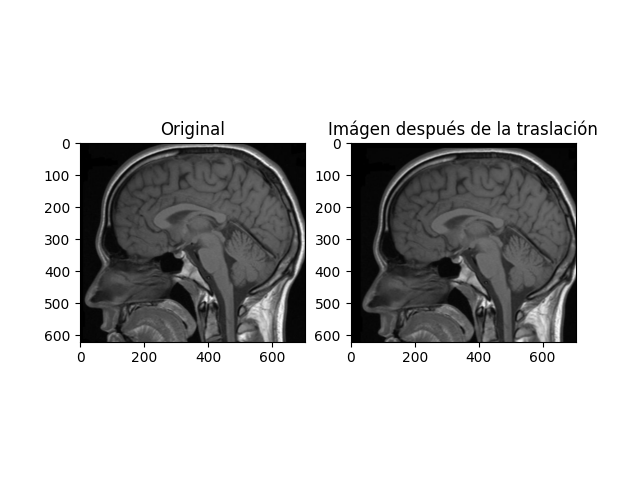

### **Ejercicio 2: Rotación**

**Procedimiento:**

Con el entorno preparado de la parte de traslación, para aplicar la rotación, obtenemos las coordenadas del centro de la imagen, para dividir el ancho y alto entre los dos, se aplica de esta manera para que la rotación se realice de manera simétrica. Después multiplicamos por la matriz de rotación con estos valores de ancho y alto de la imagen, aplicando de nuevo el warp.Affine con los datos de la matriz de rotación para obtener la imagen rotada.


**Código:**

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("labpdi4pt2.jpg")
rows, cols = img. shape [ : 2]

M_rot = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 1)
img_rot = cv2.warpAffine(img, M_rot, (cols, rows))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Imágen original')

plt.subplot(1, 2, 2)
plt.imshow(img_rot)
plt.title('Imágen con rotación de 45°')

plt.show()

**Resultados**

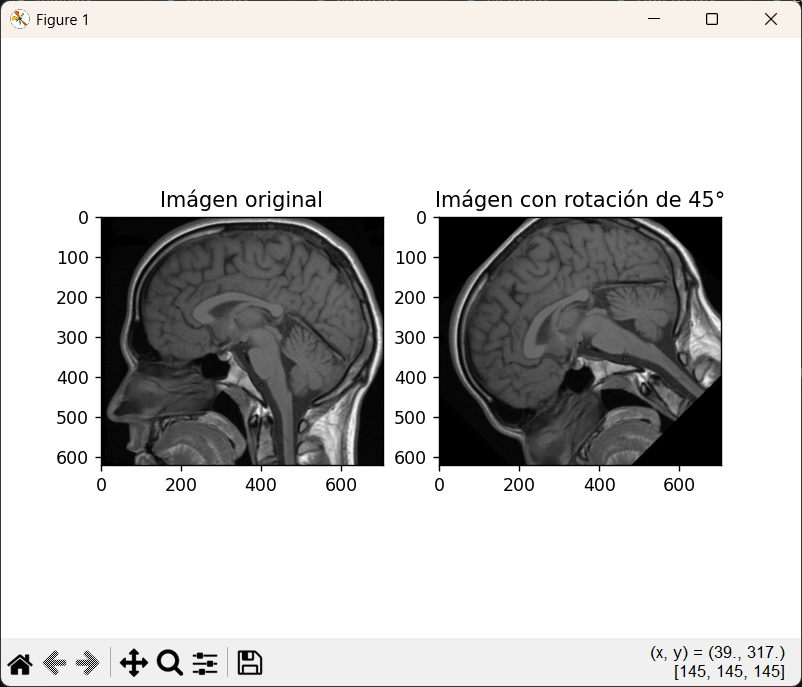

### **Ejercicio 3: Escala**

**Procedimiento:**

Dentro del escalamiento igualmente utilizado la base preparada de la imagen, en lugar de aplicar la matriz para calcular los píxeles, definimos los factores fx y fy para alternar las dimensiones. Un valor mayor a 1 es el que aumenta el tamaño y menos a 1 el que lo disminuye. Utilizamos inter_cubic para este paso final de escalado, que utiliza como base un entorno de 4x4 píxeles para promediar más lento pero preserva mejor los bordes, esto aplicado dentro del escalamiento de resize para llevarlo a cabo el escalamiento.


**Código:**

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("labpdi4pt2.jpg")
rows, cols = img. shape [ : 2]

img_150 = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)
img_50 = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title('Imágen original')

plt.subplot(1, 3, 2)
plt.imshow(img_150)
plt.title('Imágen escalada al 150%')

plt.subplot(1, 3, 3)
plt.imshow(img_50)
plt.title('Imágen escalada al 50%')

plt.show()

**Resultados**

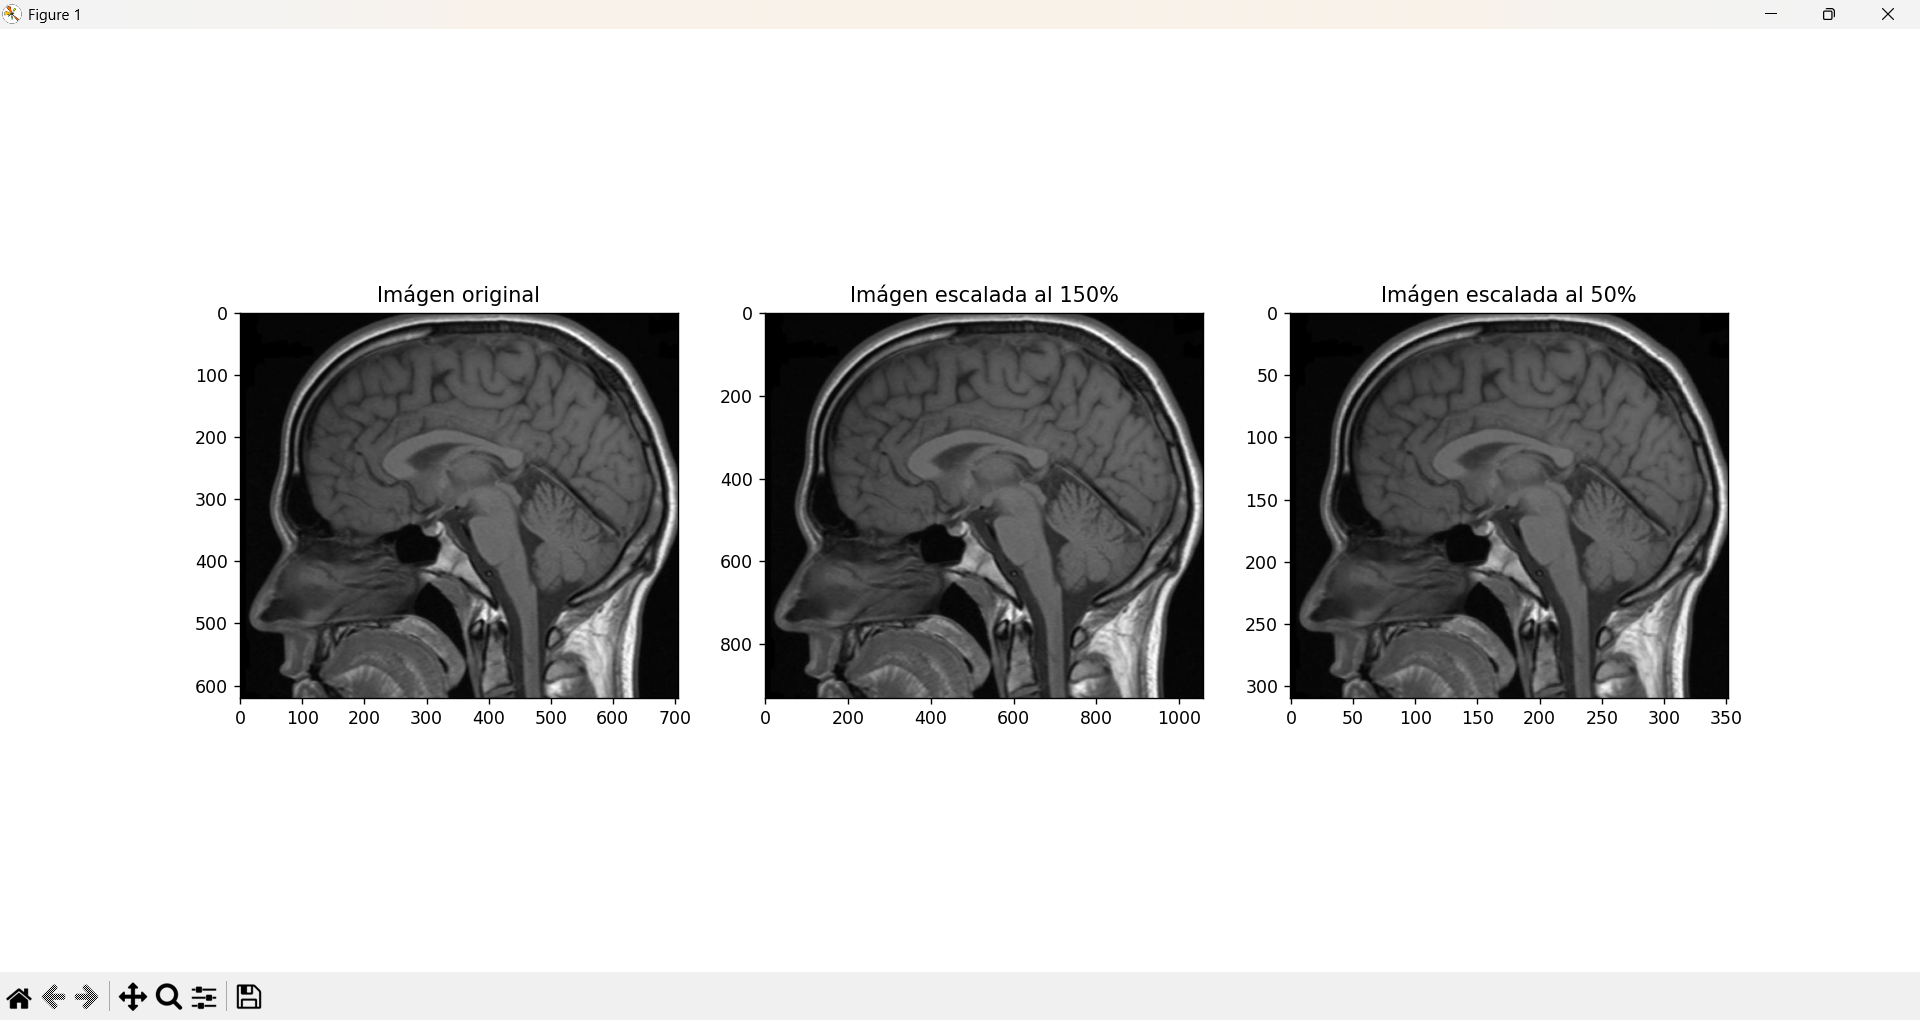

## **Parte II**

### **Ejercicio 1: Ecualización**

Imágen usada para esta parte:

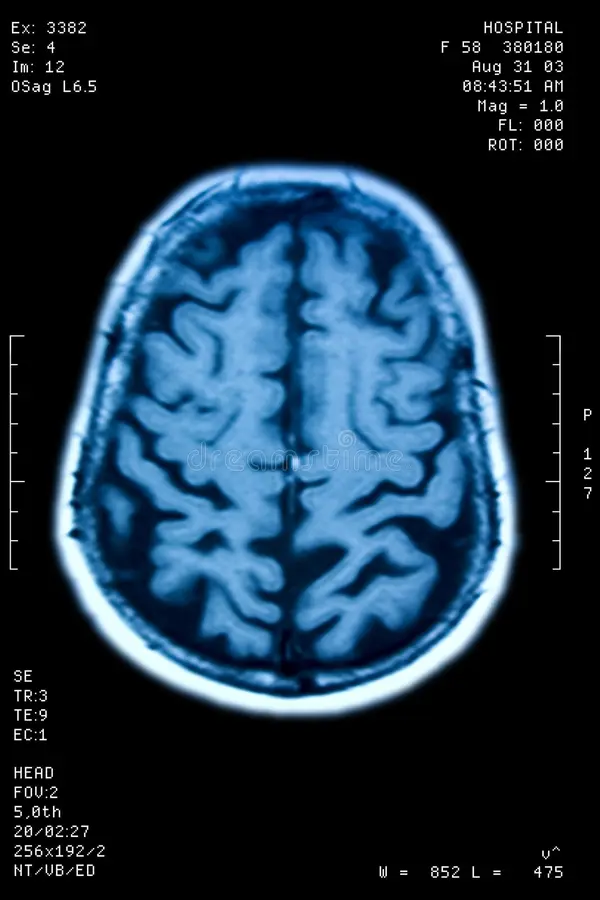

**Procedimiento:**

Primero cargamos la imágen, la convertimos a escala de grises y la guardamos como “img”. Después con esa imágen usamos “cv2.calcHist” para calcular el histograma de la nueva imágen a escala de grises, para luego hacer un subplot y mostrar la imágen y su histograma lado a lado. Ahora usamos la función “cv2.equalizeHist” para ecualizar el histograma que ya teníamos. Ya ecualizado el histograma, mostramos de nuevo la imágen cambiada. Al final también hacemos un subplot mostrando la imágen en grises, su histograma, la imágen después de ecualizar el histograma y dicho histograma ecualizado.


**Código:**

In [ ]:
import cv2
import matplotlib.pyplot as plt


img = cv2.imread('labpdi4pt2.5.jpg', 0)


histor = cv2.calcHist([img],[0],None,[256],[0,256])
plt.subplot(1, 2, 2)
plt.hist(histor)
plt.title('Histograma de escala de grises')

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imágen en grises')

plt.show()


ec = cv2.equalizeHist(img)
plt.subplot(2, 2, 3)
plt.imshow(ec, cmap='gray')
plt.title('Imágen mejorada después de ecualizar el histograma')

histec = cv2.calcHist([ec],[0],None,[256],[0,256])
plt.subplot(2, 2, 4)
plt.hist(histec)
plt.title('Histograma ecualizado')

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imágen en grises')

plt.subplot(2, 2, 2)
plt.hist(histor)
plt.title('Histograma de escala de grises')


plt.show()

**Resultados**

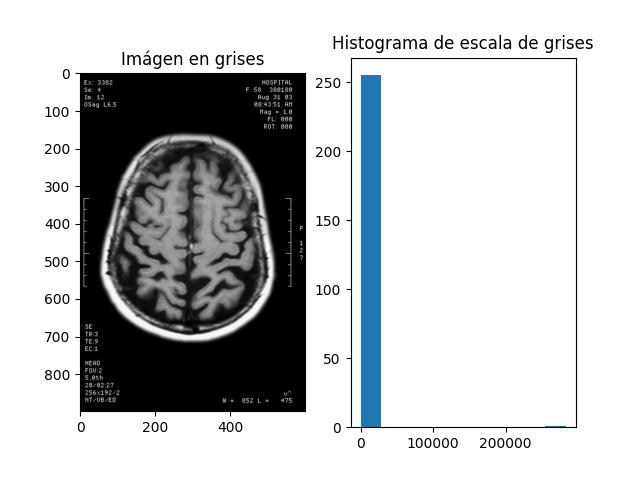

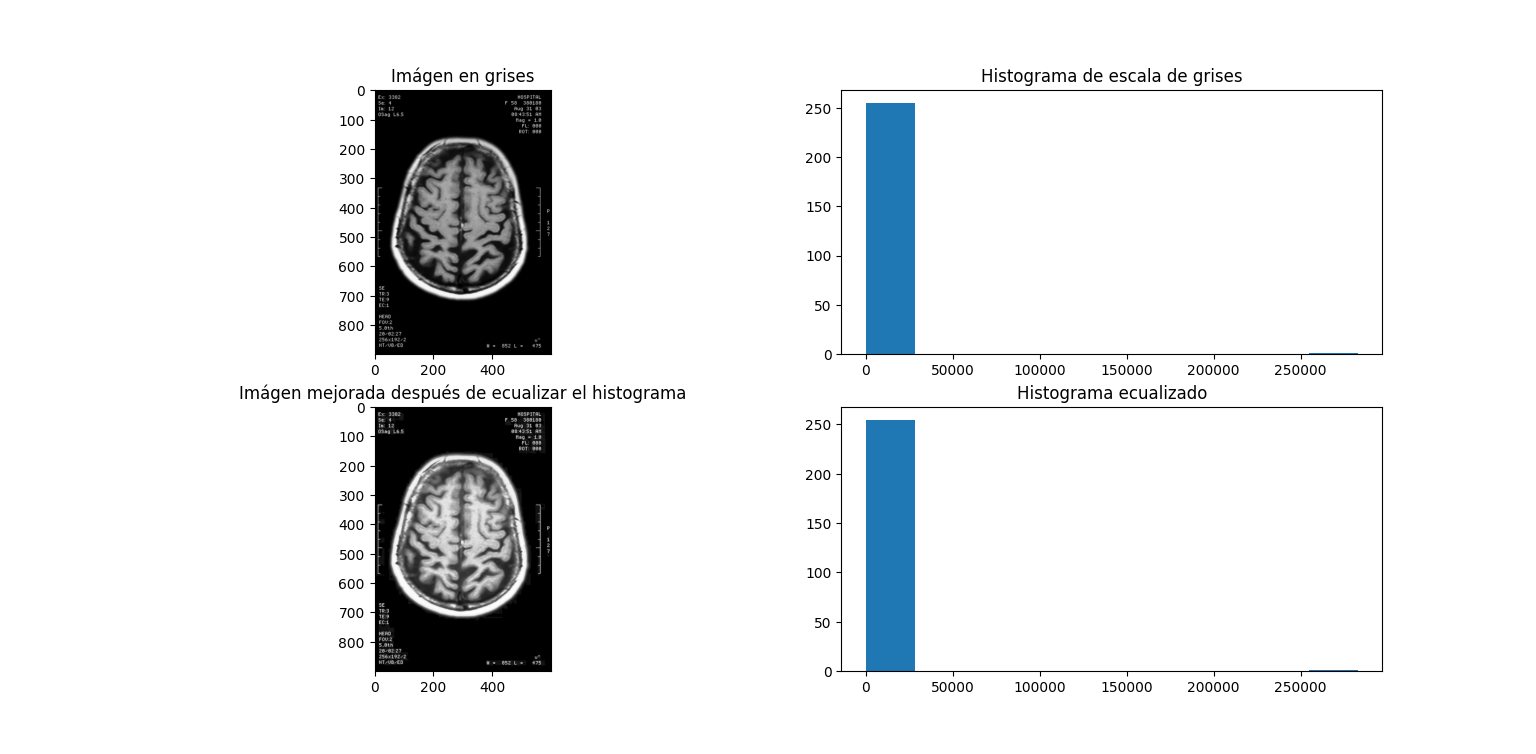

**Conclusión**

Esta práctica nos ayudó a comprender acerca de la preparación de la imagen para aplicarle a esta base los distintos procedimientos que utilizamos, dentro de los cuales se destaca el procesamiento geométrico que hace referencia a la traslación y rotación, donde logramos establecer primero la referencia, para luego obtener las variables necesarias que funcionan para crear la matriz que transforma los valores base y nos da la imagen resultante. Por otro lado, la integración de la ecualización del histograma nos ofrece un complemento a la primera fase de la práctica, que mientras en la primera fase conseguimos cambiar la forma de la imagen, en la ecualización transformamos el contenido, expandiendo el rango de contraste a uno más dinámico, técnicamente mejorando la estética de la imagen y aumentando la relación señal/ruido a una más estable, para facilitar futuros procesamientos o detecciones de la imagen.